In [27]:

!pip install -q stop-words

import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as mcolors

from scipy.sparse import hstack
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from stop_words import get_stop_words

In [28]:
# Load Dataset

file_path = "/content/Dataset_tickets_multilang.csv"
df = pd.read_csv(file_path)
print(f"✅ Dataset Loaded Successfully. Shape: {df.shape}")
df[['subject', 'body', 'queue', 'priority', 'language']].head()

✅ Dataset Loaded Successfully. Shape: (20000, 15)


,subject,body,queue,priority,language
0,Unvorhergesehener Absturz der Datenanalyse-Pla...,Die Datenanalyse-Plattform brach unerwartet ab...,General Inquiry,low,de
1,Customer Support Inquiry,Seeking information on digital strategies that...,Customer Service,medium,en
2,Data Analytics for Investment,I am contacting you to request information on ...,Customer Service,medium,en
3,Krankenhaus-Dienstleistung-Problem,Ein Medien-Daten-Sperrverhalten trat aufgrund ...,Customer Service,high,de
4,Security,"Dear Customer Support, I am reaching out to in...",Customer Service,medium,en


In [29]:
# Prepare text and target columns

df = df.dropna(subset=['body'])
df['subject'] = df['subject'].fillna('')
df['queue'] = df['queue'].fillna('Unknown')
df['priority'] = df['priority'].fillna('Unknown')
df['language'] = df['language'].fillna('Unknown')
df['text'] = df['subject'] + ' ' + df['body']

TEXT_COL = 'text'
LABEL_COL = 'type'
META_COLS = ['queue', 'priority', 'language']   # extra signal jo pehle use nahi ho raha tha
print(f"✅ Missing values handled. Remaining rows: {df.shape[0]}")

✅ Missing values handled. Remaining rows: 19998


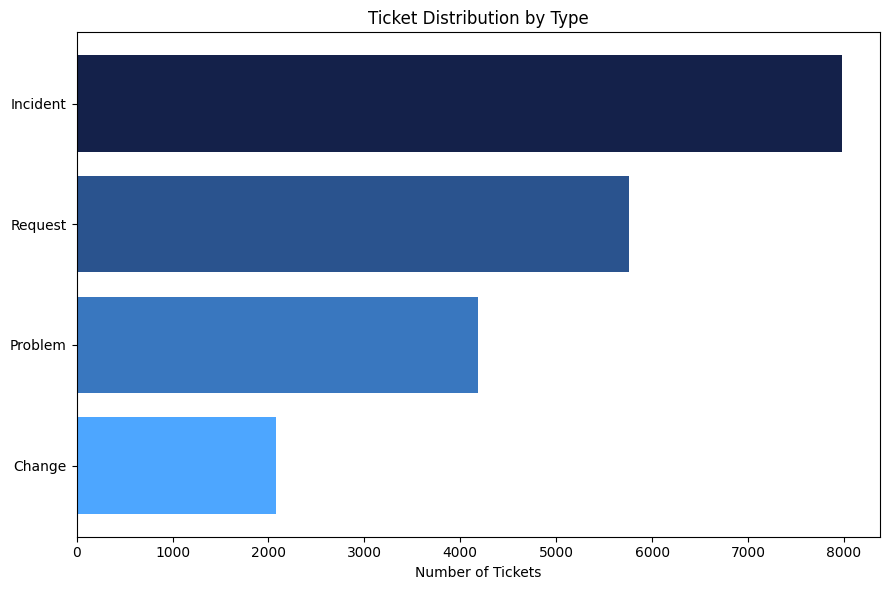

In [30]:
# GRAPH 1: Ticket Type distribution

counts = df[LABEL_COL].value_counts().sort_values()
norm_raw = mcolors.Normalize(vmin=counts.values.min(), vmax=counts.values.max())
black_blue_cmap = mcolors.LinearSegmentedColormap.from_list("black_blue", ["#0a0a2a", "#4da6ff"])


bar_colors = [black_blue_cmap(0.15 + 0.85 * (1 - norm_raw(v))) for v in counts.values]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(counts.index, counts.values, color=bar_colors)
ax.set_xlabel("Number of Tickets")
ax.set_title("Ticket Distribution by Type")
plt.tight_layout()
plt.savefig('type_distribution.png', dpi=150)
plt.show()

In [31]:
# Text cleaning: lowercase, strip URLs/HTML/punctuation/numbers, remove stopwords

STOPWORDS_EN_DE = set(get_stop_words('en')) | set(get_stop_words('de'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'\w*\d\w*', '', text)
    tokens = [t for t in text.split() if t not in STOPWORDS_EN_DE and len(t) > 1]
    return ' '.join(tokens)

df['clean_text'] = df[TEXT_COL].apply(clean_text)
print("✅ Data cleaning done — text lowercased, URLs/HTML/punctuation/numbers/stopwords removed.")

✅ Data cleaning done — text lowercased, URLs/HTML/punctuation/numbers/stopwords removed.


In [32]:
# Train-test split (stratified on label)

train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df[LABEL_COL]
)
y_train = train_df[LABEL_COL]
y_test = test_df[LABEL_COL]
y = df[LABEL_COL]   # GRAPH 3 me poore label set ke liye use hoga
print(f"✅ Train-test split done. Train size: {train_df.shape[0]}, Test size: {test_df.shape[0]}")

✅ Train-test split done. Train size: 15998, Test size: 4000


In [33]:
# TF-IDF vectorization + meta-feature encoding

tfidf = TfidfVectorizer(max_features=30000, ngram_range=(1, 2), min_df=2, max_df=0.9, sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(train_df['clean_text'])
X_test_tfidf = tfidf.transform(test_df['clean_text'])

ohe = OneHotEncoder(handle_unknown='ignore')
X_train_meta = ohe.fit_transform(train_df[META_COLS])
X_test_meta = ohe.transform(test_df[META_COLS])

X_train_final = hstack([X_train_tfidf, X_train_meta]).tocsr()
X_test_final = hstack([X_test_tfidf, X_test_meta]).tocsr()
print(f"✅ TF-IDF + meta vectorization done. Final feature count: {X_train_final.shape[1]}")

✅ TF-IDF + meta vectorization done. Final feature count: 30015


In [34]:
# Model Training & Evaluation

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, C=5.0),
    "Complement Naive Bayes": ComplementNB(),
    "Linear SVM": LinearSVC(dual='auto', C=1.0, max_iter=5000)
}

results = {}
predictions = {}
print("\n" + "="*50)
print(" MODEL TRAINING & EVALUATION RESULTS ")
print("="*50)

for name, model in models.items():
    model.fit(X_train_final, y_train)
    y_pred = model.predict(X_test_final)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    predictions[name] = y_pred

    print(f"\n---> {name} <---")
    print(f"Accuracy: {acc * 100:.2f}%")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("-" * 50)

best_model_name = max(results, key=results.get)
print(f"\nBest Performing Model: {best_model_name} with {results[best_model_name]*100:.2f}% accuracy.")


 MODEL TRAINING & EVALUATION RESULTS 

---> Logistic Regression <---
Accuracy: 81.58%
              precision    recall  f1-score   support

      Change       0.96      0.87      0.91       415
    Incident       0.76      0.85      0.80      1595
     Problem       0.63      0.49      0.55       837
     Request       0.96      0.99      0.97      1153

    accuracy                           0.82      4000
   macro avg       0.83      0.80      0.81      4000
weighted avg       0.81      0.82      0.81      4000

--------------------------------------------------

---> Complement Naive Bayes <---
Accuracy: 76.95%
              precision    recall  f1-score   support

      Change       0.95      0.67      0.78       415
    Incident       0.69      0.96      0.80      1595
     Problem       0.75      0.15      0.25       837
     Request       0.87      1.00      0.93      1153

    accuracy                           0.77      4000
   macro avg       0.82      0.69      0.69      4

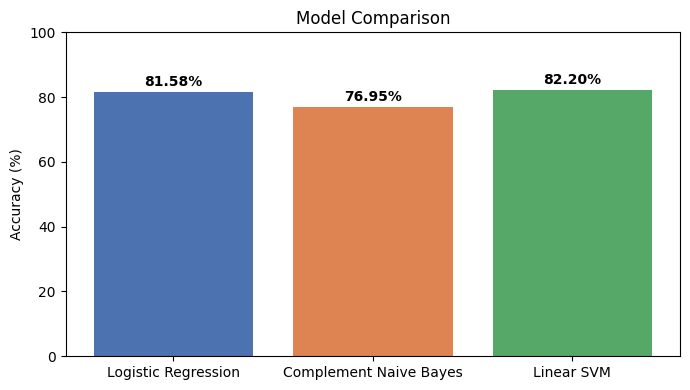

In [35]:
# GRAPH 2: Model comparison

results_pct = {name: acc * 100 for name, acc in results.items()}
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(results_pct.keys(), results_pct.values(), color=['#4C72B0', '#DD8452', '#55A868'])
ax.set_ylabel("Accuracy (%)")
ax.set_title("Model Comparison")
ax.set_ylim(0, 100)
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%",
             ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

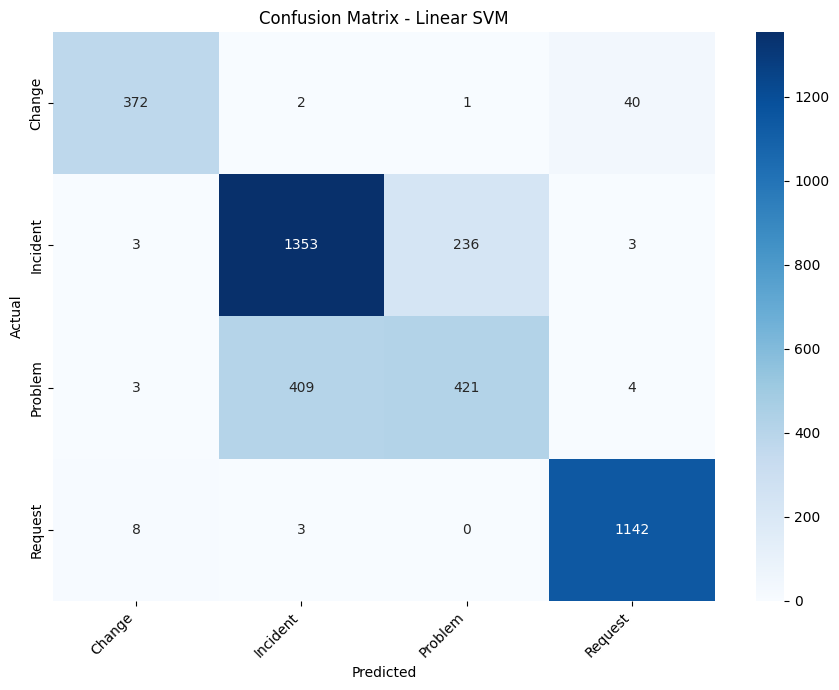

In [36]:
# GRAPH 3: Confusion matrix (best model)

cm_matrix = confusion_matrix(y_test, predictions[best_model_name], labels=sorted(y.unique()))
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()), ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix - {best_model_name}")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()